# Analyse exploratoire — creditcard
EDA préalable à la recherche automatisée de modèles ML.

## 1. Setup & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

## 2. Configuration

In [2]:
# ── À adapter pour chaque dataset ──────────────────────────────────────────
DATA_PATH   = "../data/00_raw/creditcard.csv"
TARGET_COL  = "Class"
TASK        = "classification"
DROP_COLS   = []
# ───────────────────────────────────────────────────────────────────────────

## 3. Chargement des données

In [3]:
df = pd.read_csv(DATA_PATH)
if DROP_COLS:
    df.drop(columns=DROP_COLS, inplace=True)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
features = [c for c in df.columns if c != TARGET_COL]
num_features = df[features].select_dtypes(include="number").columns.tolist()
cat_features = df[features].select_dtypes(exclude="number").columns.tolist()
print(f"Features numériques ({len(num_features)}) : {num_features}")
print(f"Features catégorielles ({len(cat_features)}) : {cat_features}")
df[num_features].describe()

Features numériques (30) : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Features catégorielles (0) : []


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


## 4. Qualité des données

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print("Valeurs manquantes :")
display(pd.DataFrame({"count": missing, "%": missing_pct})[missing > 0])

print(f"\nDoublons : {df.duplicated().sum()}")

Valeurs manquantes :


,count,%



Doublons : 1081


In [7]:
if TASK == "classification":
    print("Distribution de la cible :")
    vc = df[TARGET_COL].value_counts()
    display(pd.DataFrame({"count": vc, "%": (vc / len(df) * 100).round(2)}))
else:
    print("Distribution de la cible (régression) :")
    display(df[[TARGET_COL]].describe())
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    df[TARGET_COL].hist(bins=30, ax=axes[0])
    axes[0].set_title(f"Histogramme — {TARGET_COL}")
    sns.boxplot(y=df[TARGET_COL], ax=axes[1])
    axes[1].set_title(f"Boxplot — {TARGET_COL}")
    plt.tight_layout()
    plt.show()

Distribution de la cible :


,count,%
Class,,
0,284315,99.83
1,492,0.17


## 5. Analyse exploratoire (EDA)

### 5.1 Distribution des features numériques

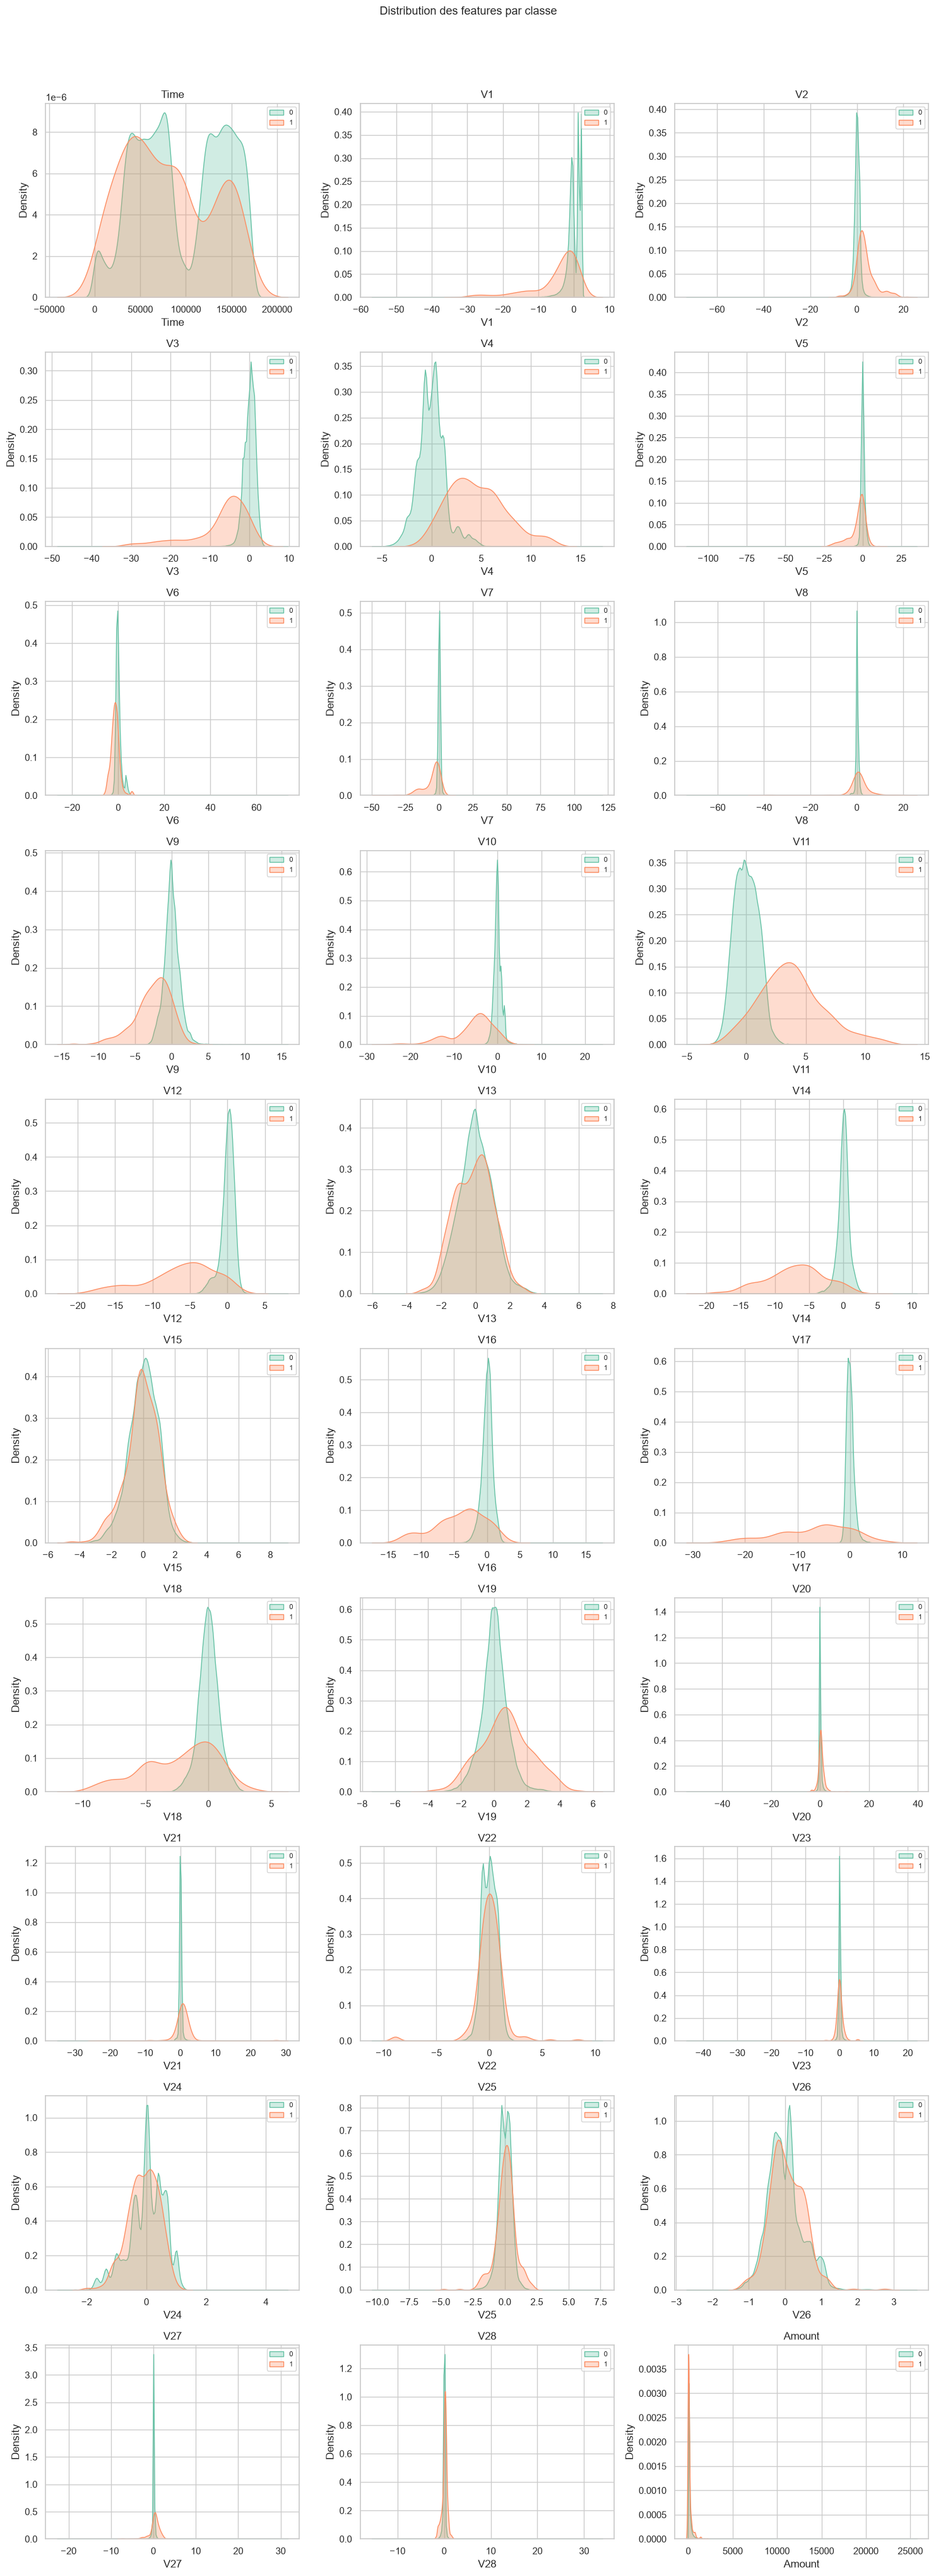

In [8]:
if num_features:
    n = len(num_features)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flat

    for ax, feat in zip(axes, num_features):
        if TASK == "classification":
            for label, grp in df.groupby(TARGET_COL):
                sns.kdeplot(grp[feat], ax=ax, label=str(label), fill=True, alpha=0.3)
            ax.legend(fontsize=8)
        else:
            sns.histplot(df[feat], ax=ax, kde=True)
        ax.set_title(feat)

    for ax in list(axes)[n:]:
        ax.set_visible(False)

    title = "Distribution des features par classe" if TASK == "classification" else "Distribution des features"
    plt.suptitle(title, y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

### 5.2 Heatmap des corrélations

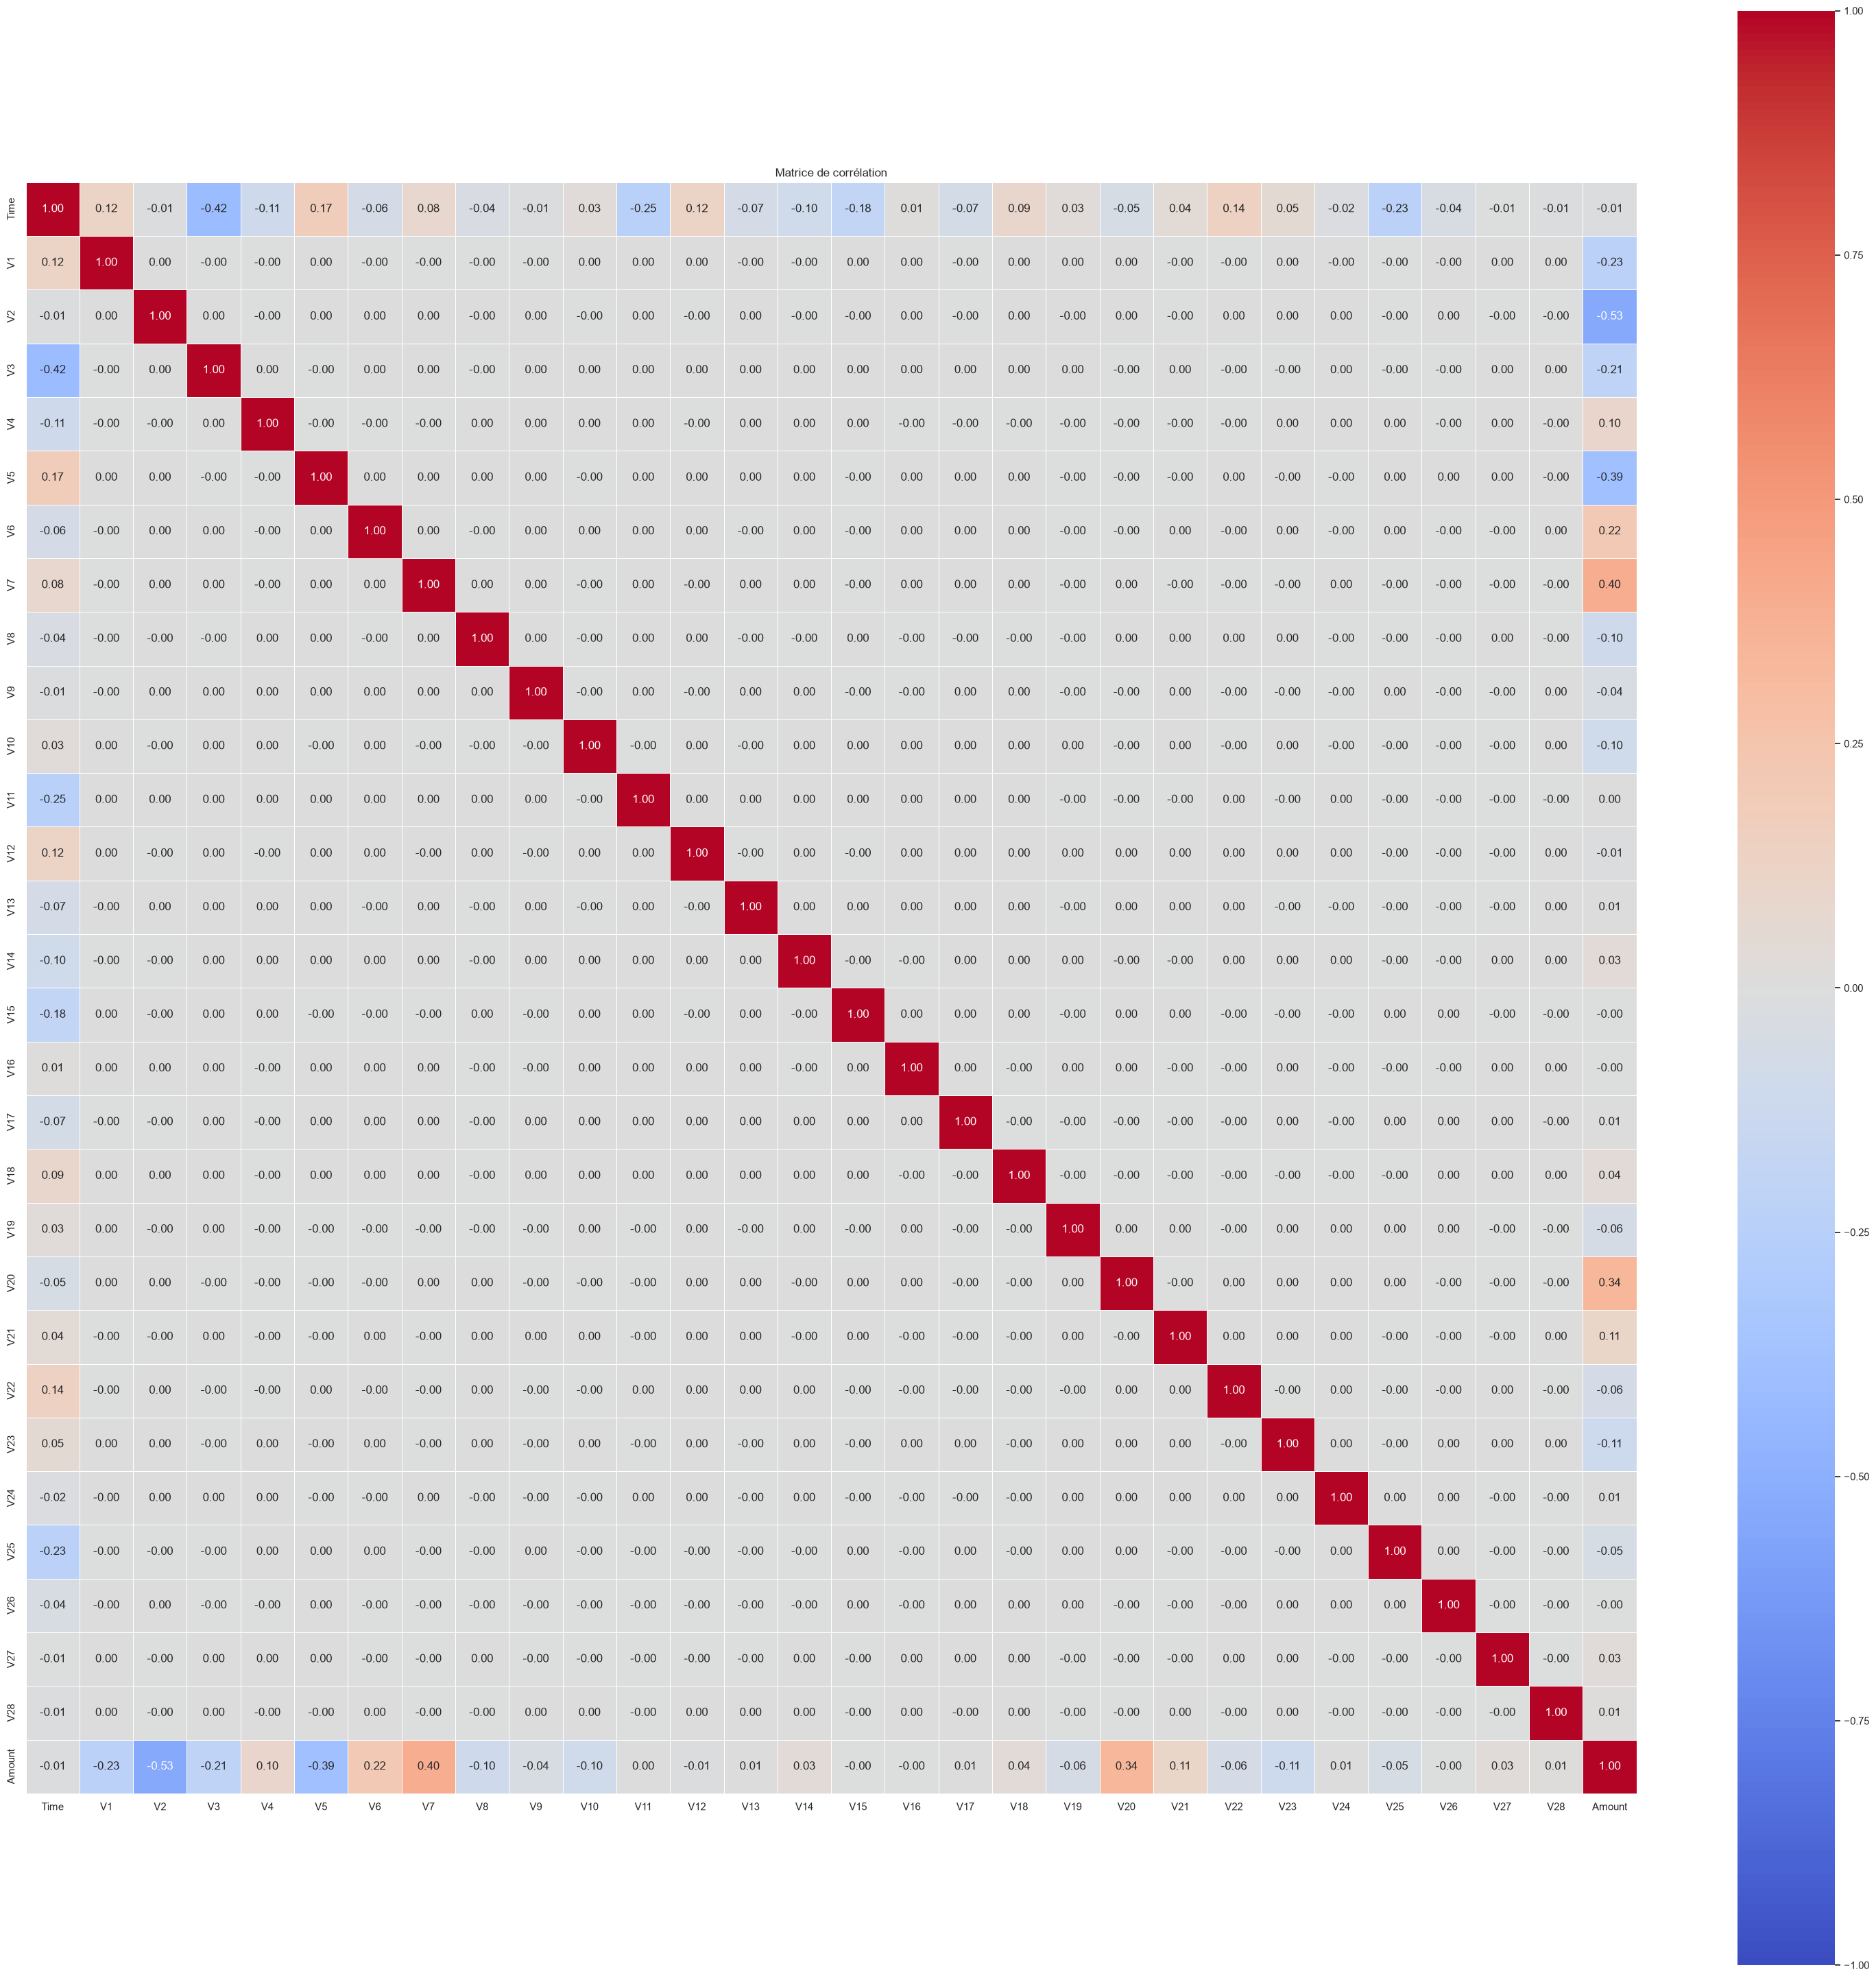

In [9]:
if num_features:
    corr_cols = num_features + ([TARGET_COL] if TASK == "regression" else [])
    corr = df[corr_cols].corr()
    plt.figure(figsize=(max(6, len(corr_cols)), max(5, len(corr_cols) - 1)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, linewidths=0.5)
    plt.title("Matrice de corrélation")
    plt.tight_layout()
    plt.show()

### 5.3 Pairplot

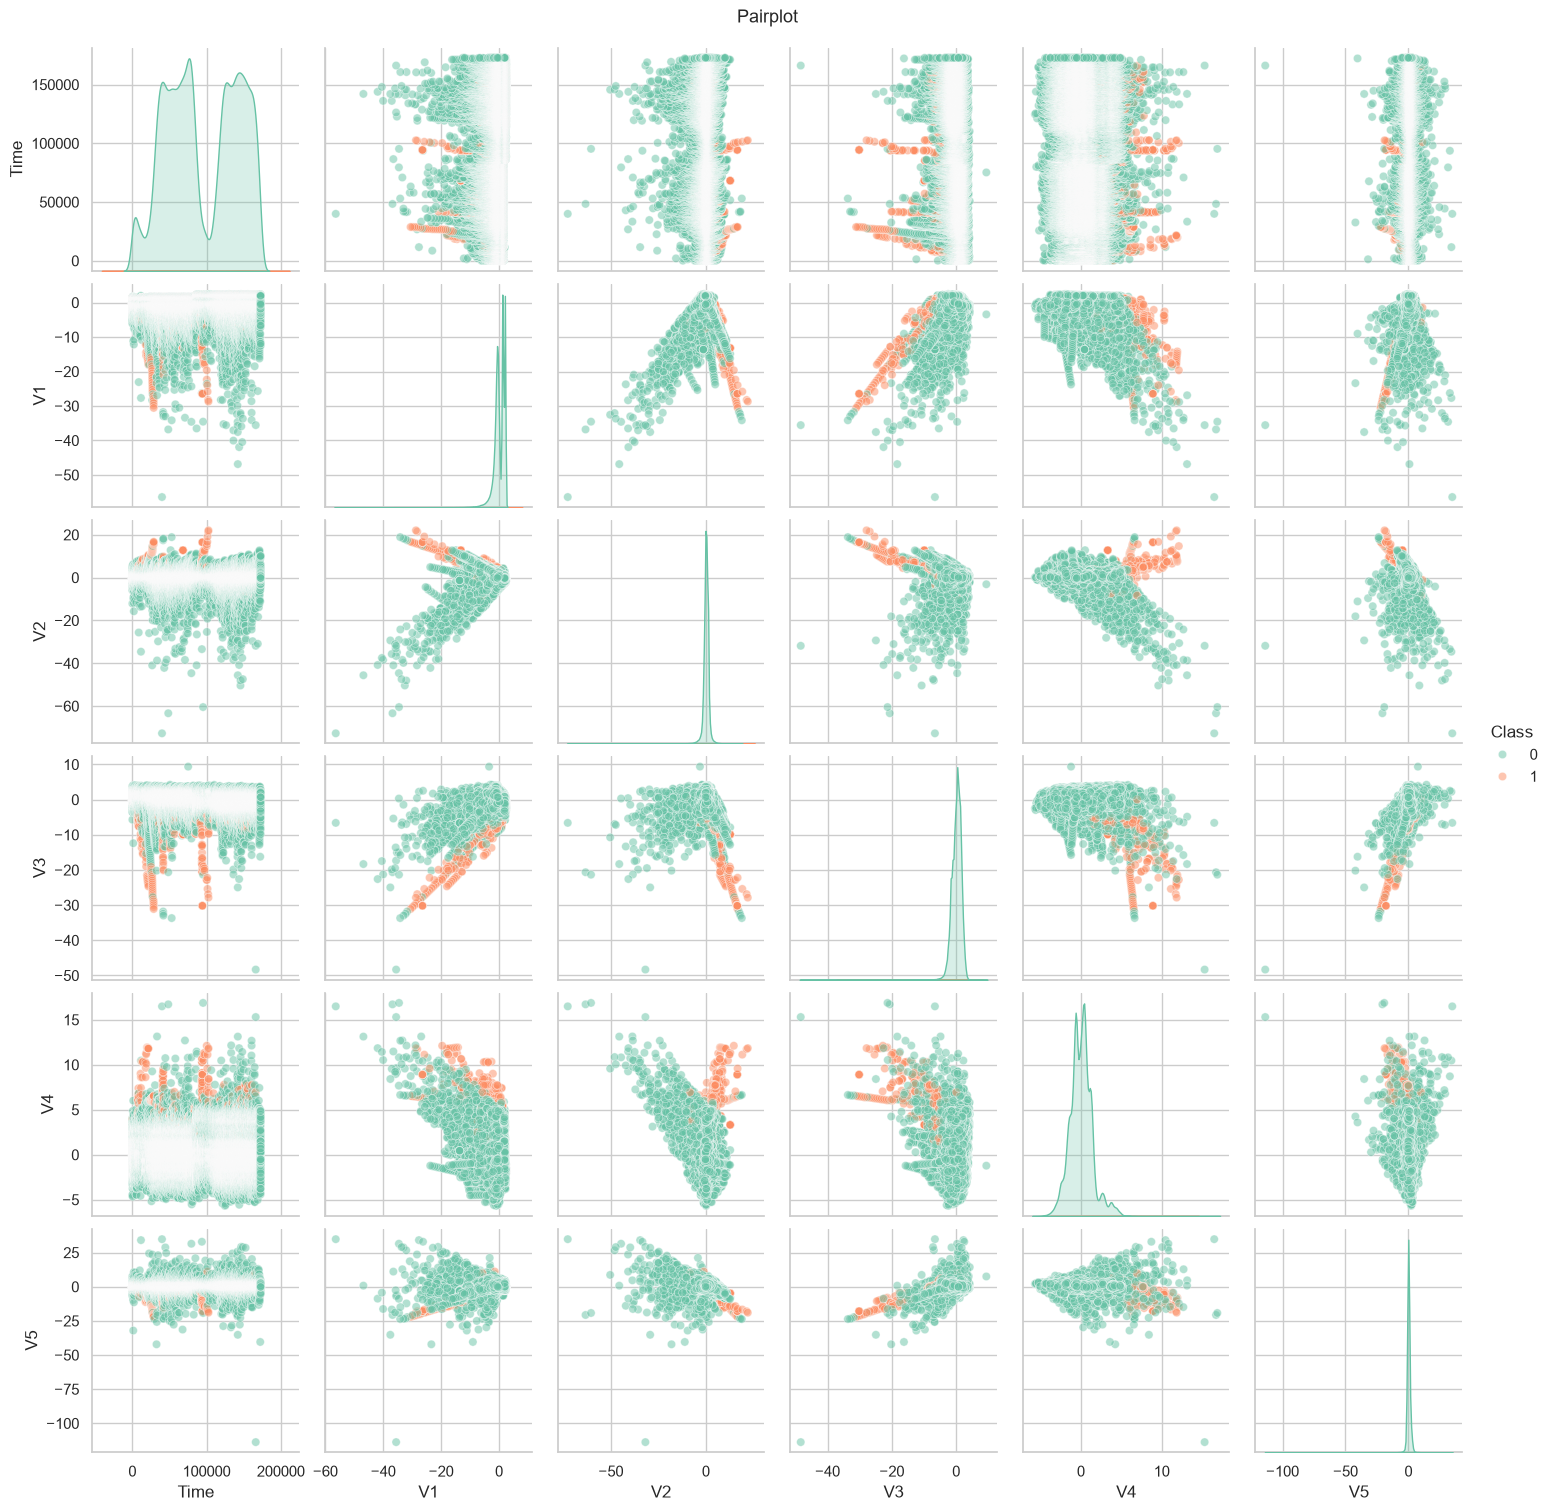

In [10]:
# Limiter aux features les plus importantes si le dataset est large
MAX_PAIRPLOT_FEATURES = 6
pair_cols = num_features[:MAX_PAIRPLOT_FEATURES]

if pair_cols:
    hue = TARGET_COL if TASK == "classification" else None
    sns.pairplot(df[pair_cols + ([TARGET_COL] if hue else [])],
                 hue=hue, diag_kind="kde", plot_kws={"alpha": 0.5})
    plt.suptitle("Pairplot", y=1.01, fontsize=13)
    plt.show()

### 5.4 Boxplots par classe (classification)

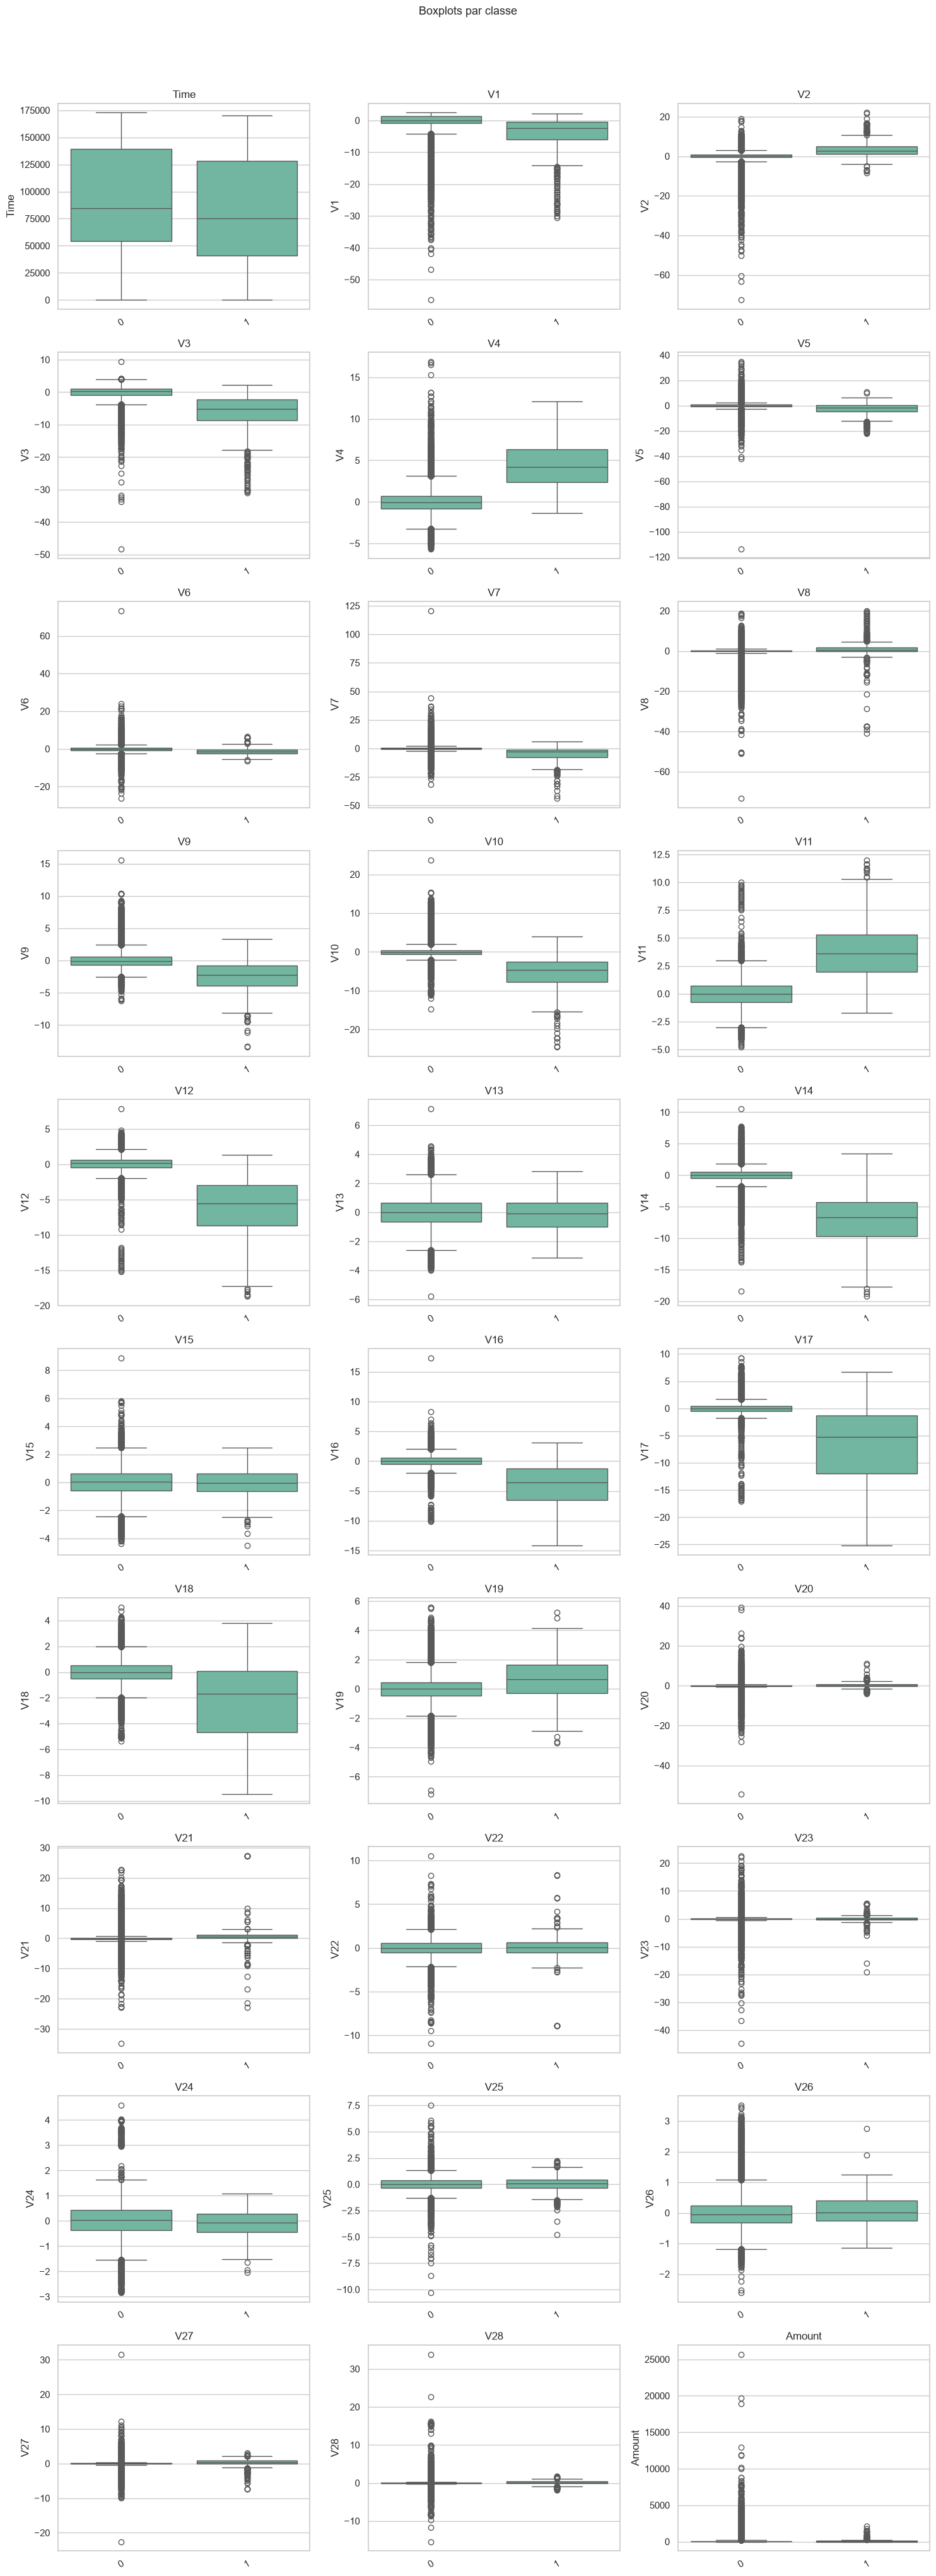

In [11]:
if TASK == "classification" and num_features:
    n = len(num_features)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flat

    for ax, feat in zip(axes, num_features):
        sns.boxplot(data=df, x=TARGET_COL, y=feat, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

    for ax in list(axes)[n:]:
        ax.set_visible(False)

    plt.suptitle("Boxplots par classe", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()

### 5.5 Features catégorielles

In [12]:
if cat_features:
    n = len(cat_features)
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).flat

    for ax, feat in zip(axes, cat_features):
        df[feat].value_counts().plot(kind="bar", ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)

    for ax in list(axes)[n:]:
        ax.set_visible(False)

    plt.suptitle("Distribution des features catégorielles", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune feature catégorielle.")

Aucune feature catégorielle.


## 6. Tableau récapitulatif

In [13]:
if TASK == "classification" and num_features:
    summary = df.groupby(TARGET_COL)[num_features].agg(["mean", "std"]).round(2)
    summary.columns = [" ".join(col) for col in summary.columns]
    display(summary)
else:
    display(df[num_features].describe().round(2))

,Time mean,Time std,V1 mean,V1 std,V2 mean,V2 std,V3 mean,V3 std,V4 mean,V4 std,...,V25 mean,V25 std,V26 mean,V26 std,V27 mean,V27 std,V28 mean,V28 std,Amount mean,Amount std
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.20,47484.02,0.01,1.93,-0.01,1.64,0.01,1.46,-0.01,1.40,...,-0.00,0.52,-0.00,0.48,-0.00,0.40,-0.00,0.33,88.29,250.11
1,80746.81,47835.37,-4.77,6.78,3.62,4.29,-7.03,7.11,4.54,2.87,...,0.04,0.80,0.05,0.47,0.17,1.38,0.08,0.55,122.21,256.68


## 7. Conclusion

**Features les plus discriminantes :**
- …

**Corrélations :**
- …

**Qualité des données :**
- Valeurs manquantes : …
- Doublons : …
- Équilibre des classes : …

**Implications pour le ML :**
- Type de tâche : …
- Baseline attendue : …
- Points d'attention : …